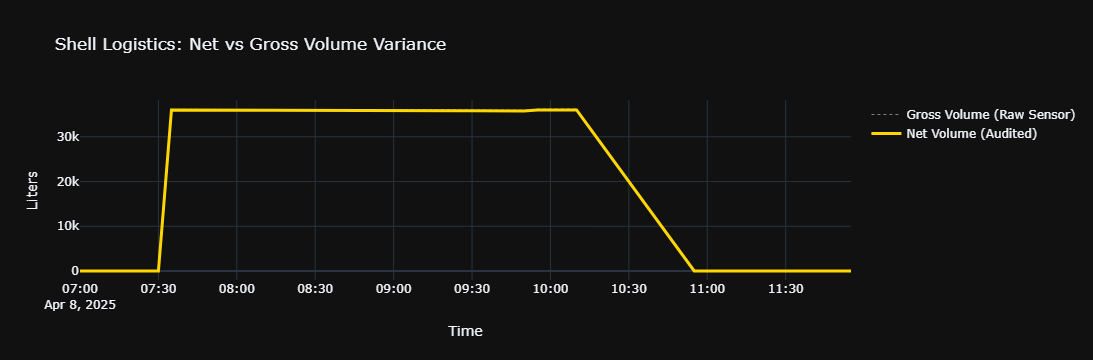

In [1]:
import pandas as pd
import plotly.graph_objects as go
import os

# Path handling
path = '../data/processed/shell_katy_audited_2025.csv'
if not os.path.exists(path): path = 'data/processed/shell_katy_audited_2025.csv'

df = pd.read_csv(path)

fig = go.Figure()

# Gross Volume (The raw sensor - influenced by heat)
fig.add_trace(go.Scatter(x=df['timestamp'], y=df['gross_volume_l'],
                    name='Gross Volume (Raw Sensor)',
                    line=dict(color='gray', width=1, dash='dot')))

# Net Volume (The audited truth - 15°C)
fig.add_trace(go.Scatter(x=df['timestamp'], y=df['net_volume_l'],
                    name='Net Volume (Audited)',
                    line=dict(color='#FFD700', width=3)))

fig.update_layout(title='Shell Logistics: Net vs Gross Volume Variance',
                  xaxis_title='Time', yaxis_title='Liters',
                  template='plotly_dark', hovermode='x unified')
fig.show()

In [3]:
# Filter for Transit phase only
transit_df = df[df['phase'].str.contains("Transit", na=False)]

# 1. Find Valve Violations
valve_alerts = transit_df[transit_df['valve_status'].str.contains("Open", na=False)]

# 2. Find Steep Volume Drops (Rate of Change)
# Flag any drop greater than 15 Liters in a 5-minute window
transit_df['loss_rate'] = transit_df['net_volume_l'].diff()
steep_loss = transit_df[transit_df['loss_rate'] < -15]

print("SECURITY & INTEGRITY INCIDENT REPORT")
if not valve_alerts.empty:
    for i, row in valve_alerts.iterrows():
        print(f"ALERT: Unauthorized Valve Opening at {row['timestamp']}")
        print(f"   Location: https://www.google.com/maps?q={row['latitude']},{row['longitude']}")
else:
    print("Valve Security: Integrity maintained throughout journey.")

if not steep_loss.empty:
    print(f"ALERT: Sustained Product Loss detected! Total Loss in Transit: {abs(transit_df['loss_rate'].sum()):.2f} L")

SECURITY & INTEGRITY INCIDENT REPORT
ALERT: Unauthorized Valve Opening at 2025-04-08 09:15:00
   Location: https://www.google.com/maps?q=29.74947,-95.4512
ALERT: Sustained Product Loss detected! Total Loss in Transit: 248.53 L


In [8]:
# 1. Define local variables for the report
TRUCK_ID = "SHL-TX-9921"  # Matches our Phase 1 ID

# 2. Calculate real loss during transit only
# We use the 'transit_df' created in Cell 2
transit_start = transit_df['net_volume_l'].iloc[0]
transit_end = transit_df['net_volume_l'].iloc[-1]
actual_transit_loss = transit_end - transit_start

# 3. Generate the Executive Summary
report = f"""
EXECUTIVE SUMMARY
-----------------
Mission: Shell Deer Park Terminal -> Katy Retail
Truck ID: {TRUCK_ID}
Status: COMPLIANCE BREACH
Calculated Transit Loss: {actual_transit_loss:.2f} Liters

Observations:
1. The destination audit technically 'Passed' because the anomaly was transient.
2. In-transit monitoring detected a {abs(actual_transit_loss):.2f}L deviation.
3. Valve sensor flagged an 'Open' state while at highway speeds.

Recommendation:
- Flag Driver assigned to {TRUCK_ID} for an immediate debrief.
- Inspect 'Submarine Valve' seal integrity for mechanical failure.
"""

print(report)


EXECUTIVE SUMMARY
-----------------
Mission: Shell Deer Park Terminal -> Katy Retail
Truck ID: SHL-TX-9921
Status: COMPLIANCE BREACH
Calculated Transit Loss: -248.53 Liters

Observations:
1. The destination audit technically 'Passed' because the anomaly was transient.
2. In-transit monitoring detected a 248.53L deviation.
3. Valve sensor flagged an 'Open' state while at highway speeds.

Recommendation:
- Flag Driver assigned to SHL-TX-9921 for an immediate debrief.
- Inspect 'Submarine Valve' seal integrity for mechanical failure.

